In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('../data/plants_final.csv')
print(f"loaded: {df.shape}")

loaded: (936, 69)


In [8]:
# similarity features
# focuses on care characteristics, use case, and physical traits
similarity_features = [
    # care
    'watering_days', 'hardiness_min', 'hardiness_max',
    'height_max_feet',
    # boolean characteristics
    'indoor', 'tropical', 'drought_tolerant', 'thorny',
    'flowers', 'fruits', 'edible_fruit', 'edible_leaf',
    'cuisine', 'medicinal', 'poisonous_to_humans', 'poisonous_to_pets',
    # engineered scores
    'beginner_score', 'drought_score', 'climate_score',
    'space_score', 'edibility_score', 'safety_score',
    # zone match
    'israel_zone_match'
]

X_sim = df[similarity_features].fillna(0).values.astype(np.float32)

scaler_sim = StandardScaler()
X_sim_scaled = scaler_sim.fit_transform(X_sim)

In [9]:
print(f"similarity matrix: {X_sim_scaled.shape}")
print(f"features used: {len(similarity_features)}")

similarity matrix: (936, 23)
features used: 23


k= 2 | inertia:  17679.6 | silhouette: 0.1834
k= 3 | inertia:  15257.3 | silhouette: 0.2178
k= 4 | inertia:  13293.3 | silhouette: 0.2382
k= 5 | inertia:  11809.7 | silhouette: 0.2163
k= 6 | inertia:  10945.5 | silhouette: 0.2132
k= 7 | inertia:  10393.0 | silhouette: 0.2175
k= 8 | inertia:   9928.5 | silhouette: 0.2137
k= 9 | inertia:   9520.2 | silhouette: 0.2253
k=10 | inertia:   9029.6 | silhouette: 0.2268
k=11 | inertia:   8771.1 | silhouette: 0.2127
k=12 | inertia:   8405.9 | silhouette: 0.2213
k=13 | inertia:   8110.4 | silhouette: 0.2258
k=14 | inertia:   7968.1 | silhouette: 0.2323
k=15 | inertia:   7704.7 | silhouette: 0.2291
k=16 | inertia:   7507.4 | silhouette: 0.2330
k=17 | inertia:   7434.4 | silhouette: 0.2291
k=18 | inertia:   7262.5 | silhouette: 0.2280
k=19 | inertia:   7125.1 | silhouette: 0.2216


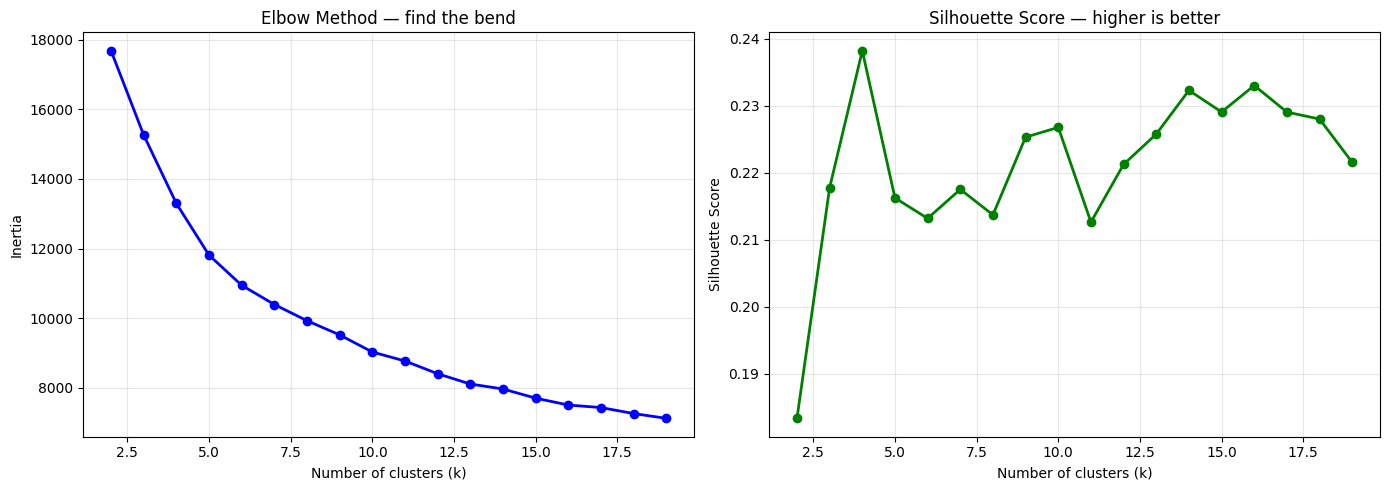


best k by silhouette: 4 (score: 0.2382)


In [10]:
# finding optimal k
inertia = []
silhouette_scores = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sim_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_sim_scaled, kmeans.labels_))
    print(f"k={k:2d} | inertia: {kmeans.inertia_:8.1f} | silhouette: {silhouette_score(X_sim_scaled, kmeans.labels_):.4f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — find the bend')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — higher is better')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nbest k by silhouette: {k_range[np.argmax(silhouette_scores)]} (score: {max(silhouette_scores):.4f})")

### model training

In [11]:
k_final = 15
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_sim_scaled)

print(f"trained kmeans with k={k_final}")
print(f"\ncluster sizes:")
print(df['cluster'].value_counts().sort_index())

print(f"\nsample clusters — what's in each one:")
for cluster_id in range(k_final):
    plants = df[df['cluster'] == cluster_id]['common_name'].values[:5]
    types = df[df['cluster'] == cluster_id]['type'].value_counts().index[0]
    print(f"\ncluster {cluster_id:2d} (dominant type: {types}):")
    print(f"  {', '.join(plants)}")

trained kmeans with k=15

cluster sizes:
cluster
0      71
1      95
2     130
3      44
4      31
5      54
6      94
7      73
8      72
9      46
10     57
11     14
12     62
13     60
14     33
Name: count, dtype: int64

sample clusters — what's in each one:

cluster  0 (dominant type: shrub):
  delta maidenhair fern, stalked aeonium, Chinese evegreen, aloe, aloe

cluster  1 (dominant type: tree):
  California Incense Cedar, Blue Chip Juniper (tree form), Yellow Variegated Tuliptree, Italian alder, Japanese falsecypress

cluster  2 (dominant type: tree):
  Ribbon-leaf Japanese Maple*, Rose Marie Magnolia, European Silver Fir, Pyramidalis Silver Fir, Candicans White Fir

cluster  3 (dominant type: tree):
  Loquat, Common Fig, Bay Laurel, pineapple guava, sea thrift

cluster  4 (dominant type: shrub):
  elephant's ear, Amazonian elephant's ear, giant elephant's ear, Sago palm, dumb cane

cluster  5 (dominant type: broadleaf evergreen):
  Guiana chestnut, eggplant, Pacific Madrone*, 

### substitution engine

In [12]:

# find similar plants in the same cluster by plant name
# ranked by overall_home_score

def get_similar_plants(plant_name, user_profile='beginner', top_n=5):
    # find plant
    plant = df[df['common_name'].str.lower() == plant_name.lower()]
    
    if len(plant) == 0:
        # try partial match
        plant = df[df['common_name'].str.lower().str.contains(plant_name.lower(), na=False)]
    
    if len(plant) == 0:
        return f"plant '{plant_name}' not found in database"
    
    plant = plant.iloc[0]
    cluster_id = plant['cluster']
    
    # get all plants in same cluster except the original
    cluster_plants = df[
        (df['cluster'] == cluster_id) & 
        (df['common_name'] != plant['common_name'])
    ].copy()
    
    # rank by overall_home_score
    cluster_plants = cluster_plants.sort_values('overall_home_score', ascending=False)
    
    print(f"\n'{plant['common_name']}' is in cluster {cluster_id}")
    print(f"cluster has {len(cluster_plants) + 1} plants total")
    print(f"\ntop {top_n} similar plants:")
    
    cols = ['common_name', 'type', 'overall_home_score', 
            'beginner_score', 'climate_score', 'space_score']
    print(cluster_plants[cols].head(top_n).to_string(index=False))
    
    return cluster_plants.head(top_n)

# test the substitution engine
print("=== SUBSTITUTION ENGINE TEST ===")
get_similar_plants('basil')
get_similar_plants('aloe')
get_similar_plants('pothos')

# save everything
import os
os.makedirs('../models', exist_ok=True)

with open('../models/similarity_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_sim, f)

with open('../models/similarity_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('../models/similarity_features.pkl', 'wb') as f:
    pickle.dump(similarity_features, f)

# save updated dataframe with cluster assignments
df.to_csv('../data/plants_final.csv', index=False)

print("\nsaved: similarity_scaler.pkl, similarity_kmeans.pkl, similarity_features.pkl")
print("saved: plants_final.csv with cluster column")
print(f"\nModel 2 complete.")

=== SUBSTITUTION ENGINE TEST ===

'basil' is in cluster 12
cluster has 62 plants total

top 5 similar plants:
   common_name                type  overall_home_score  beginner_score  climate_score  space_score
     pennywort                herb               85.95       86.666667             85        100.0
        potato           vegetable               79.62       63.333333             85         93.0
   meyer lemon broadleaf evergreen               76.24       76.666667             85         45.0
mustard greens                herb               75.70       81.666667             85         55.0
          kale           vegetable               75.42       81.666667             85         53.0

'aloe' is in cluster 0
cluster has 69 plants total

top 5 similar plants:
              common_name   type  overall_home_score  beginner_score  climate_score  space_score
       St. Bernard's lily   herb               89.85      100.000000             78         95.0
         blue sansevieria c